# 🎧 Audio Language Model — Data Exploration

**Datasets:** ESC-50 · UrbanSound8K  
**Goal:** Understand class distributions, audio characteristics, and mel spectrogram features before building the preprocessing pipeline.

---
**Sections**
1. [Setup & Imports](#1-setup)
2. [ESC-50 Exploration](#2-esc50)
3. [UrbanSound8K Exploration](#3-urban)
4. [Cross-Dataset Comparison](#4-comparison)
5. [Mel Spectrogram Visualization](#5-melspec)
6. [Summary & Preprocessing Notes](#6-summary)

---
## 1. Setup & Imports <a id='1-setup'></a>

In [1]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
from matplotlib.patches import FancyBboxPatch
import librosa
import librosa.display
import soundfile as sf
from pathlib import Path
from collections import Counter
from tqdm import tqdm

ROOT = Path(r'C:\Users\shara\Desktop\ALM')
DATA_RAW    = ROOT / 'data' / 'raw'
ESC50_DIR   = DATA_RAW / 'esc50'
URBAN_DIR   = DATA_RAW / 'urbansound8k'

# Metadata files
ESC50_META  = ESC50_DIR  / 'meta' / 'esc50.csv'
URBAN_META  = URBAN_DIR  / 'metadata' / 'UrbanSound8K.csv'

# Verify paths
for p, name in [(ESC50_DIR, 'ESC-50'), (URBAN_DIR, 'UrbanSound8K'),
                (ESC50_META, 'ESC-50 CSV'), (URBAN_META, 'UrbanSound8K CSV')]:
    status = '✅' if p.exists() else '❌ NOT FOUND'
    print(f"{status}  {name:25s}  →  {p}")

print()
print(f'librosa  version: {librosa.__version__}')
print(f'pandas   version: {pd.__version__}')
print(f'numpy    version: {np.__version__}')

✅  ESC-50                     →  C:\Users\shara\Desktop\ALM\data\raw\esc50
✅  UrbanSound8K               →  C:\Users\shara\Desktop\ALM\data\raw\urbansound8k
✅  ESC-50 CSV                 →  C:\Users\shara\Desktop\ALM\data\raw\esc50\meta\esc50.csv
✅  UrbanSound8K CSV           →  C:\Users\shara\Desktop\ALM\data\raw\urbansound8k\metadata\UrbanSound8K.csv

librosa  version: 0.11.0
pandas   version: 2.3.3
numpy    version: 2.2.6


In [2]:
# ── Plot style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor' : '#0f0f14',
    'axes.facecolor'   : '#16161e',
    'axes.edgecolor'   : '#2a2a3a',
    'axes.labelcolor'  : '#c8c8d8',
    'axes.titlecolor'  : '#e8e8f0',
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 10,
    'xtick.color'      : '#888899',
    'ytick.color'      : '#888899',
    'xtick.labelsize'  : 8,
    'ytick.labelsize'  : 8,
    'grid.color'       : '#2a2a3a',
    'grid.linewidth'   : 0.6,
    'text.color'       : '#c8c8d8',
    'font.family'      : 'monospace',
    'figure.dpi'       : 120,
})

# Colour palettes
ESC_COLOR   = '#7eb8f7'   # soft blue  for ESC-50
URB_COLOR   = '#f79e7e'   # warm orange for UrbanSound8K
ACCENT      = '#a78bfa'   # lavender accent
GRAD_ESC    = plt.cm.Blues
GRAD_URB    = plt.cm.Oranges

print('Plot style configured.')

Plot style configured.


---
## 2. ESC-50 Exploration <a id='2-esc50'></a>

In [3]:
# ── Load metadata ───────────────────────────────────────────────────────────
esc_df = pd.read_csv(ESC50_META)
print(f'Shape : {esc_df.shape}')
print(f'Columns: {list(esc_df.columns)}')
esc_df.head()

Shape : (2000, 7)
Columns: ['filename', 'fold', 'target', 'category', 'esc10', 'src_file', 'take']


,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


In [4]:
# ── Basic statistics ────────────────────────────────────────────────────────
print('=== ESC-50 Dataset Summary ===')
print(f'  Total clips       : {len(esc_df)}')
print(f'  Unique classes    : {esc_df["category"].nunique()}')
print(f'  Clips per class   : {len(esc_df) // esc_df["category"].nunique()} (balanced)')
print(f'  Folds             : {sorted(esc_df["fold"].unique())}')
print(f'  Clips per fold    : {esc_df["fold"].value_counts().to_dict()}')

# ESC-50 has 5 super-categories — surface them if present
if 'esc10' in esc_df.columns:
    print(f'  ESC-10 subset clips: {esc_df["esc10"].sum()}')

=== ESC-50 Dataset Summary ===
  Total clips       : 2000
  Unique classes    : 50
  Clips per class   : 40 (balanced)
  Folds             : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
  Clips per fold    : {1: 400, 2: 400, 3: 400, 4: 400, 5: 400}
  ESC-10 subset clips: 400


In [ ]:
# ── Class distribution ──────────────────────────────────────────────────────
class_counts = esc_df['category'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(16, 6))
bars = ax.barh(class_counts.index, class_counts.values,
               color=ESC_COLOR, alpha=0.85, height=0.7,
               edgecolor='#1e1e2e', linewidth=0.4)

# Value labels
for bar, val in zip(bars, class_counts.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            str(val), va='center', ha='left', fontsize=7.5, color='#888899')

ax.set_xlabel('Number of clips')
ax.set_title('ESC-50 · Class Distribution  (50 classes, 40 clips each)', pad=12)
ax.set_xlim(0, class_counts.max() + 6)
ax.grid(axis='x', alpha=0.4)
ax.invert_yaxis()
fig.tight_layout()
plt.savefig(ROOT / 'outputs' / 'figures' / 'esc50_class_distribution.png',
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('Saved → outputs/figures/esc50_class_distribution.png')

KeyboardInterrupt: 

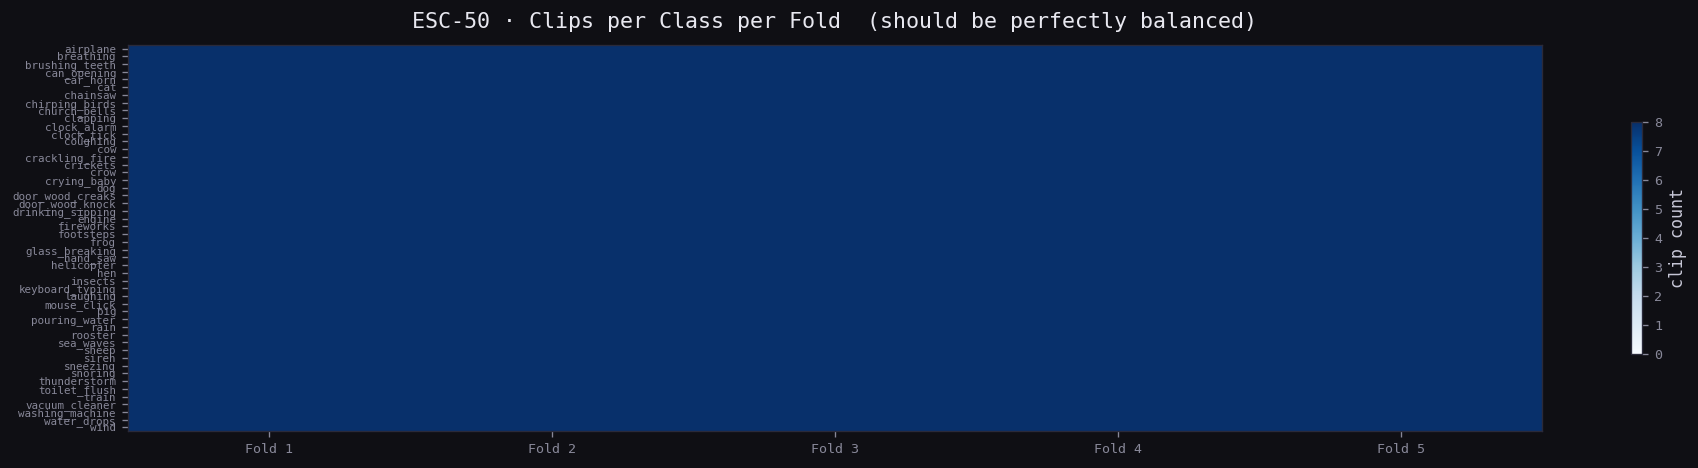

In [ ]:
# ── Fold distribution per class ─────────────────────────────────────────────
fold_class = esc_df.groupby(['fold', 'category']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(16, 4))
im = ax.imshow(fold_class.T, aspect='auto', cmap='Blues', vmin=0)
ax.set_yticks(range(len(fold_class.columns)))
ax.set_yticklabels(fold_class.columns, fontsize=6.5)
ax.set_xticks(range(len(fold_class.index)))
ax.set_xticklabels([f'Fold {i}' for i in fold_class.index], fontsize=8)
ax.set_title('ESC-50 · Clips per Class per Fold  (should be perfectly balanced)', pad=10)
plt.colorbar(im, ax=ax, shrink=0.6, label='clip count')
fig.tight_layout()
plt.savefig(ROOT / 'outputs' / 'figures' / 'esc50_fold_balance.png',
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

In [ ]:
# ── Audio duration & sample rate scan ───────────────────────────────────────
# Samples a random subset to keep things fast; set FULL_SCAN=True for all clips.
FULL_SCAN    = False
SAMPLE_N     = 100

esc_audio_dir = ESC50_DIR / 'audio'

sample_rows = esc_df if FULL_SCAN else esc_df.sample(min(SAMPLE_N, len(esc_df)), random_state=42)

esc_stats = []
for _, row in tqdm(sample_rows.iterrows(), total=len(sample_rows), desc='Scanning ESC-50'):
    fpath = esc_audio_dir / row['filename']
    if not fpath.exists():
        continue
    try:
        info = sf.info(str(fpath))
        esc_stats.append({
            'filename'   : row['filename'],
            'category'   : row['category'],
            'fold'       : row['fold'],
            'sample_rate': info.samplerate,
            'channels'   : info.channels,
            'duration_s' : info.duration,
            'frames'     : info.frames,
        })
    except Exception as e:
        print(f'  ⚠ Could not read {fpath.name}: {e}')

esc_stats_df = pd.DataFrame(esc_stats)
print(f'\nScanned {len(esc_stats_df)} files')
esc_stats_df[['sample_rate','channels','duration_s']].describe().round(3)

Scanning ESC-50: 100%|██████████| 100/100 [00:01<00:00, 57.37it/s]


Scanned 100 files


,sample_rate,channels,duration_s
count,100.0,100.0,100.0
mean,44100.0,1.0,5.0
std,0.0,0.0,0.0
min,44100.0,1.0,5.0
25%,44100.0,1.0,5.0
50%,44100.0,1.0,5.0
75%,44100.0,1.0,5.0
max,44100.0,1.0,5.0


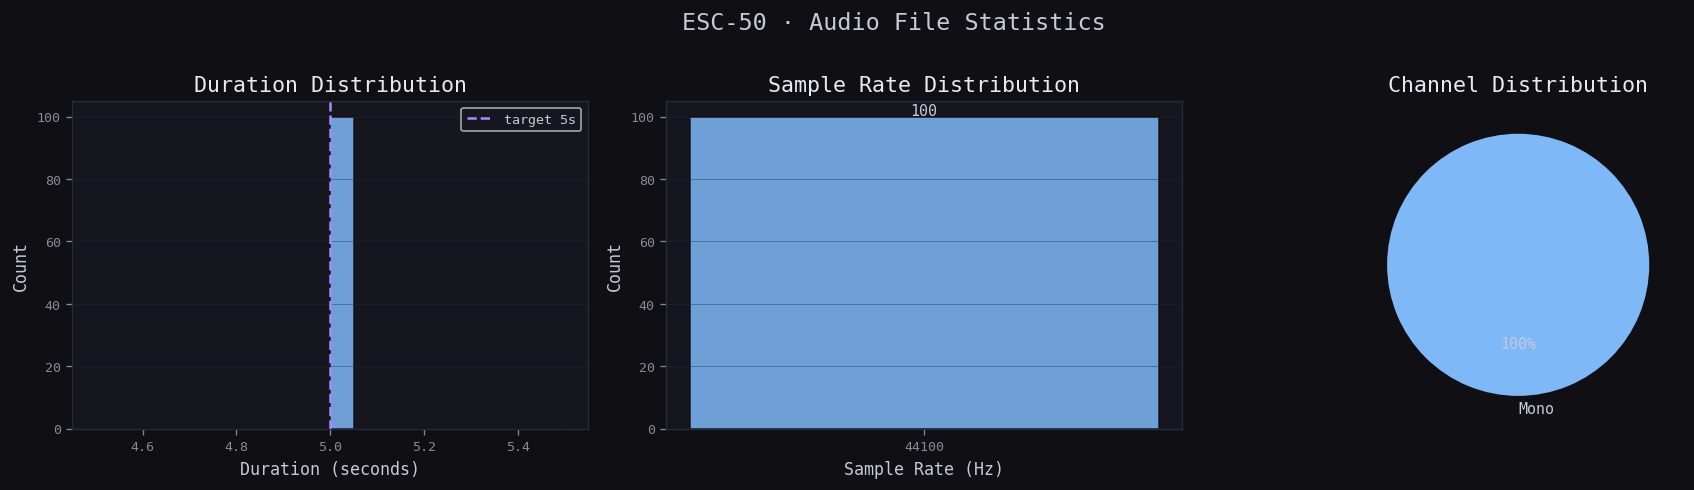

In [ ]:
# ── ESC-50 audio stats plots ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('ESC-50 · Audio File Statistics', fontsize=14, y=1.01)

# Duration distribution
ax = axes[0]
ax.hist(esc_stats_df['duration_s'], bins=20, color=ESC_COLOR, alpha=0.85, edgecolor='#0f0f14')
ax.axvline(5.0, color=ACCENT, lw=1.5, linestyle='--', label='target 5s')
ax.set_xlabel('Duration (seconds)')
ax.set_ylabel('Count')
ax.set_title('Duration Distribution')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.4)

# Sample rate distribution
ax = axes[1]
sr_counts = esc_stats_df['sample_rate'].value_counts()
ax.bar(sr_counts.index.astype(str), sr_counts.values, color=ESC_COLOR, alpha=0.85, edgecolor='#0f0f14')
ax.set_xlabel('Sample Rate (Hz)')
ax.set_ylabel('Count')
ax.set_title('Sample Rate Distribution')
ax.grid(axis='y', alpha=0.4)
for i, (label, val) in enumerate(zip(sr_counts.index.astype(str), sr_counts.values)):
    ax.text(i, val + 0.5, str(val), ha='center', fontsize=9, color='#c8c8d8')

# Channel distribution
ax = axes[2]
ch_counts = esc_stats_df['channels'].value_counts()
labels = ['Mono' if c == 1 else 'Stereo' if c == 2 else str(c) for c in ch_counts.index]
wedges, texts, autotexts = ax.pie(
    ch_counts.values, labels=labels, autopct='%1.0f%%',
    colors=[ESC_COLOR, ACCENT, URB_COLOR][:len(ch_counts)],
    startangle=90, textprops={'fontsize': 9}
)
ax.set_title('Channel Distribution')

fig.tight_layout()
plt.savefig(ROOT / 'outputs' / 'figures' / 'esc50_audio_stats.png',
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

---
## 3. UrbanSound8K Exploration <a id='3-urban'></a>

In [ ]:
# ── Load metadata ───────────────────────────────────────────────────────────
urb_df = pd.read_csv(URBAN_META)
print(f'Shape  : {urb_df.shape}')
print(f'Columns: {list(urb_df.columns)}')
urb_df.head()

Shape  : (8732, 8)
Columns: ['slice_file_name', 'fsID', 'start', 'end', 'salience', 'fold', 'classID', 'class']


,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing


In [ ]:
# ── Basic statistics ────────────────────────────────────────────────────────
print('=== UrbanSound8K Dataset Summary ===')
print(f'  Total clips       : {len(urb_df)}')
print(f'  Unique classes    : {urb_df["class"].nunique()}')
print(f'  Folds             : {sorted(urb_df["fold"].unique())}')
print(f'  Clips per fold    : ')
print(urb_df["fold"].value_counts().sort_index().to_string())
print(f'\n  Class names       : {sorted(urb_df["class"].unique())}')

=== UrbanSound8K Dataset Summary ===
  Total clips       : 8732
  Unique classes    : 10
  Folds             : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
  Clips per fold    : 
fold
1     873
2     888
3     925
4     990
5     936
6     823
7     838
8     806
9     816
10    837

  Class names       : ['air_conditioner', 'car_horn', 'children_playing', 'dog_bark', 'drilling', 'engine_idling', 'gun_shot', 'jackhammer', 'siren', 'street_music']


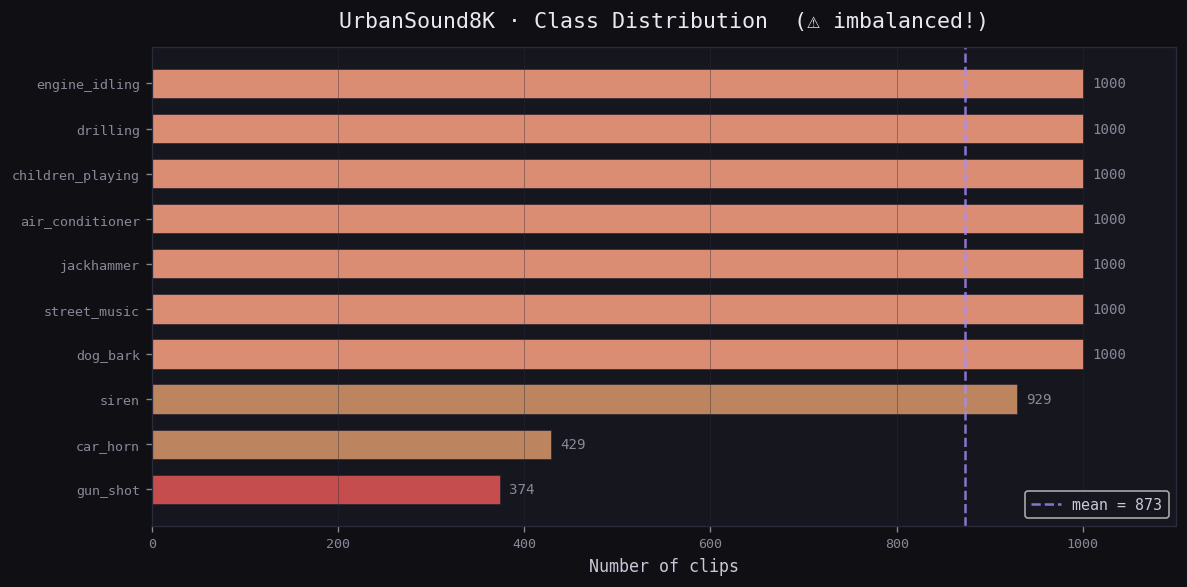

In [ ]:
# ── Class distribution (imbalanced!) ───────────────────────────────────────
urb_class_counts = urb_df['class'].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors = [URB_COLOR if v == urb_class_counts.max() else
          '#e05555' if v == urb_class_counts.min() else
          '#d4956a' for v in urb_class_counts.values]
bars = ax.barh(urb_class_counts.index, urb_class_counts.values,
               color=colors, alpha=0.88, height=0.65, edgecolor='#1e1e2e', linewidth=0.4)

for bar, val in zip(bars, urb_class_counts.values):
    ax.text(val + 10, bar.get_y() + bar.get_height()/2,
            str(val), va='center', ha='left', fontsize=8.5, color='#888899')

# Highlight imbalance
avg = urb_class_counts.mean()
ax.axvline(avg, color=ACCENT, lw=1.5, linestyle='--', alpha=0.8, label=f'mean = {avg:.0f}')
ax.set_xlabel('Number of clips')
ax.set_title('UrbanSound8K · Class Distribution  (⚠ imbalanced!)', pad=12)
ax.set_xlim(0, urb_class_counts.max() + 100)
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.4)
fig.tight_layout()
plt.savefig(ROOT / 'outputs' / 'figures' / 'urban_class_distribution.png',
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

In [ ]:
# ── Audio duration & sample rate scan ───────────────────────────────────────
FULL_SCAN = False
SAMPLE_N  = 150

urb_audio_dir = URBAN_DIR / 'audio'
sample_rows   = urb_df if FULL_SCAN else urb_df.sample(min(SAMPLE_N, len(urb_df)), random_state=42)

urb_stats = []
for _, row in tqdm(sample_rows.iterrows(), total=len(sample_rows), desc='Scanning UrbanSound8K'):
    fpath = urb_audio_dir / f'fold{row["fold"]}' / row['slice_file_name']
    if not fpath.exists():
        continue
    try:
        info = sf.info(str(fpath))
        urb_stats.append({
            'filename'   : row['slice_file_name'],
            'class'      : row['class'],
            'fold'       : row['fold'],
            'sample_rate': info.samplerate,
            'channels'   : info.channels,
            'duration_s' : info.duration,
        })
    except Exception as e:
        print(f'  ⚠ {fpath.name}: {e}')

urb_stats_df = pd.DataFrame(urb_stats)
print(f'\nScanned {len(urb_stats_df)} files')
urb_stats_df[['sample_rate','channels','duration_s']].describe().round(3)

Scanning UrbanSound8K: 100%|██████████| 150/150 [00:00<00:00, 1563.82it/s]


Scanned 150 files


,sample_rate,channels,duration_s
count,150.000,150.000,150.000
mean,48296.167,1.920,3.600
std,14303.360,0.272,0.949
min,11025.000,1.000,0.106
25%,44100.000,2.000,4.000
50%,44100.000,2.000,4.000
75%,48000.000,2.000,4.000
max,96000.000,2.000,4.000


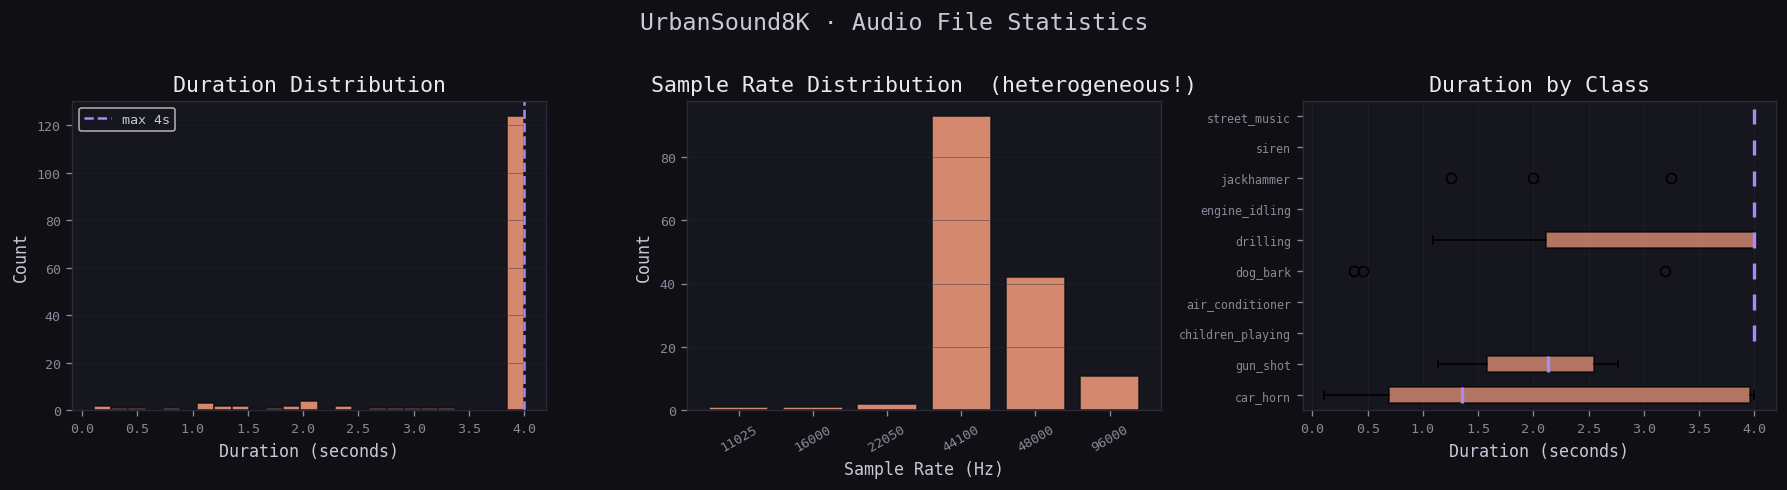

In [ ]:
# ── UrbanSound8K audio stats plots ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('UrbanSound8K · Audio File Statistics', fontsize=14, y=1.01)

# Duration distribution
ax = axes[0]
ax.hist(urb_stats_df['duration_s'], bins=25, color=URB_COLOR, alpha=0.85, edgecolor='#0f0f14')
ax.axvline(4.0, color=ACCENT, lw=1.5, linestyle='--', label='max 4s')
ax.set_xlabel('Duration (seconds)')
ax.set_ylabel('Count')
ax.set_title('Duration Distribution')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.4)

# Sample rate distribution
ax = axes[1]
sr_counts = urb_stats_df['sample_rate'].value_counts().sort_index()
ax.bar(sr_counts.index.astype(str), sr_counts.values, color=URB_COLOR, alpha=0.85, edgecolor='#0f0f14')
ax.set_xlabel('Sample Rate (Hz)')
ax.set_ylabel('Count')
ax.set_title('Sample Rate Distribution  (heterogeneous!)')
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', alpha=0.4)

# Duration per class (boxplot)
ax = axes[2]
classes_ordered = urb_stats_df.groupby('class')['duration_s'].median().sort_values().index
data_by_class   = [urb_stats_df[urb_stats_df['class'] == c]['duration_s'].values
                   for c in classes_ordered]
bp = ax.boxplot(data_by_class, vert=False, patch_artist=True,
                medianprops=dict(color=ACCENT, linewidth=2))
for patch in bp['boxes']:
    patch.set_facecolor(URB_COLOR)
    patch.set_alpha(0.7)
ax.set_yticks(range(1, len(classes_ordered)+1))
ax.set_yticklabels(classes_ordered, fontsize=7)
ax.set_xlabel('Duration (seconds)')
ax.set_title('Duration by Class')
ax.grid(axis='x', alpha=0.4)

fig.tight_layout()
plt.savefig(ROOT / 'outputs' / 'figures' / 'urban_audio_stats.png',
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

---
## 4. Cross-Dataset Comparison <a id='4-comparison'></a>

In [ ]:
# ── Side-by-side comparison table ───────────────────────────────────────────
comparison = pd.DataFrame({
    'Property'   : ['Total clips', 'Classes', 'Folds', 'Duration',
                    'Sample rate(s)', 'Class balance', 'Target SR → 16kHz'],
    'ESC-50'     : ['2,000', '50', '5', '5s (fixed)',
                    '44,100 Hz', 'Balanced (40/class)', 'Downsample ×2.75'],
    'UrbanSound8K': ['8,732', '10', '10', '≤4s (variable)',
                     'Mixed (22k/44k/…)', 'Imbalanced', 'Resample + pad to 5s'],
})
comparison.set_index('Property', inplace=True)
display(comparison.style
    .set_table_styles([{'selector': 'th', 'props': [('background-color', '#1e1e2e'),
                                                     ('color', '#a78bfa'),
                                                     ('font-family', 'monospace')]}])
)

,ESC-50,UrbanSound8K
Property,,
Total clips,"2,000","8,732"
Classes,50,10
Folds,5,10
Duration,5s (fixed),≤4s (variable)
Sample rate(s),"44,100 Hz",Mixed (22k/44k/…)
Class balance,Balanced (40/class),Imbalanced
Target SR → 16kHz,Downsample ×2.75,Resample + pad to 5s


In [ ]:
# ── Overlapping classes between the two datasets ────────────────────────────
esc_classes  = set(esc_df['category'].unique())
urb_classes  = set(urb_df['class'].unique())
overlap      = esc_classes & urb_classes

print(f'ESC-50 classes       : {len(esc_classes)}')
print(f'UrbanSound8K classes : {len(urb_classes)}')
print(f'Overlapping classes  : {len(overlap)}')
if overlap:
    print(f'  → {sorted(overlap)}')
else:
    print('  → No exact name matches (check for semantic overlaps manually)')

ESC-50 classes       : 50
UrbanSound8K classes : 10
Overlapping classes  : 2
  → ['car_horn', 'siren']


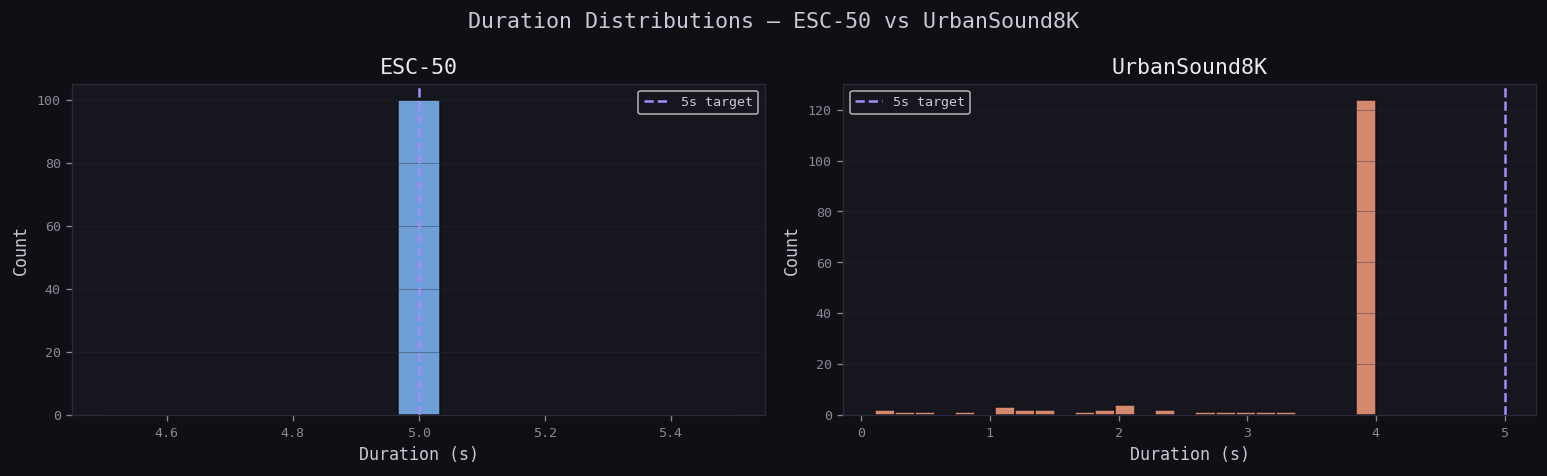

In [ ]:
# ── Duration distributions side by side ─────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4), sharey=False)
fig.suptitle('Duration Distributions — ESC-50 vs UrbanSound8K', fontsize=13)

ax1.hist(esc_stats_df['duration_s'], bins=15, color=ESC_COLOR, alpha=0.85, edgecolor='#0f0f14')
ax1.axvline(5.0, color=ACCENT, lw=1.5, linestyle='--', label='5s target')
ax1.set_title('ESC-50')
ax1.set_xlabel('Duration (s)')
ax1.set_ylabel('Count')
ax1.legend(fontsize=8)
ax1.grid(axis='y', alpha=0.4)

ax2.hist(urb_stats_df['duration_s'], bins=25, color=URB_COLOR, alpha=0.85, edgecolor='#0f0f14')
ax2.axvline(5.0, color=ACCENT, lw=1.5, linestyle='--', label='5s target')
ax2.set_title('UrbanSound8K')
ax2.set_xlabel('Duration (s)')
ax2.set_ylabel('Count')
ax2.legend(fontsize=8)
ax2.grid(axis='y', alpha=0.4)

fig.tight_layout()
plt.savefig(ROOT / 'outputs' / 'figures' / 'duration_comparison.png',
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

---
## 5. Mel Spectrogram Visualization <a id='5-melspec'></a>

In [ ]:
# ── Mel spectrogram helper ───────────────────────────────────────────────────

# Target format (from project config)
TARGET_SR   = 16_000
TARGET_DUR  = 5.0          # seconds
N_FFT       = 1024
HOP_LENGTH  = 512
N_MELS      = 128

def load_and_normalize(filepath: str,
                       sr: int = TARGET_SR,
                       duration: float = TARGET_DUR) -> np.ndarray:
    """Load audio, convert to mono, resample, pad/trim to fixed duration."""
    y, orig_sr = librosa.load(filepath, sr=sr, mono=True)
    target_len = int(sr * duration)
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)), mode='constant')
    else:
        y = y[:target_len]
    return y


def compute_melspec(y: np.ndarray, sr: int = TARGET_SR) -> np.ndarray:
    """Compute log-scaled mel spectrogram."""
    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS
    )
    return librosa.power_to_db(mel, ref=np.max)


print('Helper functions defined.')
print(f'  TARGET_SR  = {TARGET_SR} Hz')
print(f'  DURATION   = {TARGET_DUR} s')
print(f'  N_MELS     = {N_MELS}')
print(f'  N_FFT      = {N_FFT}')
print(f'  HOP_LENGTH = {HOP_LENGTH}')

Helper functions defined.
  TARGET_SR  = 16000 Hz
  DURATION   = 5.0 s
  N_MELS     = 128
  N_FFT      = 1024
  HOP_LENGTH = 512


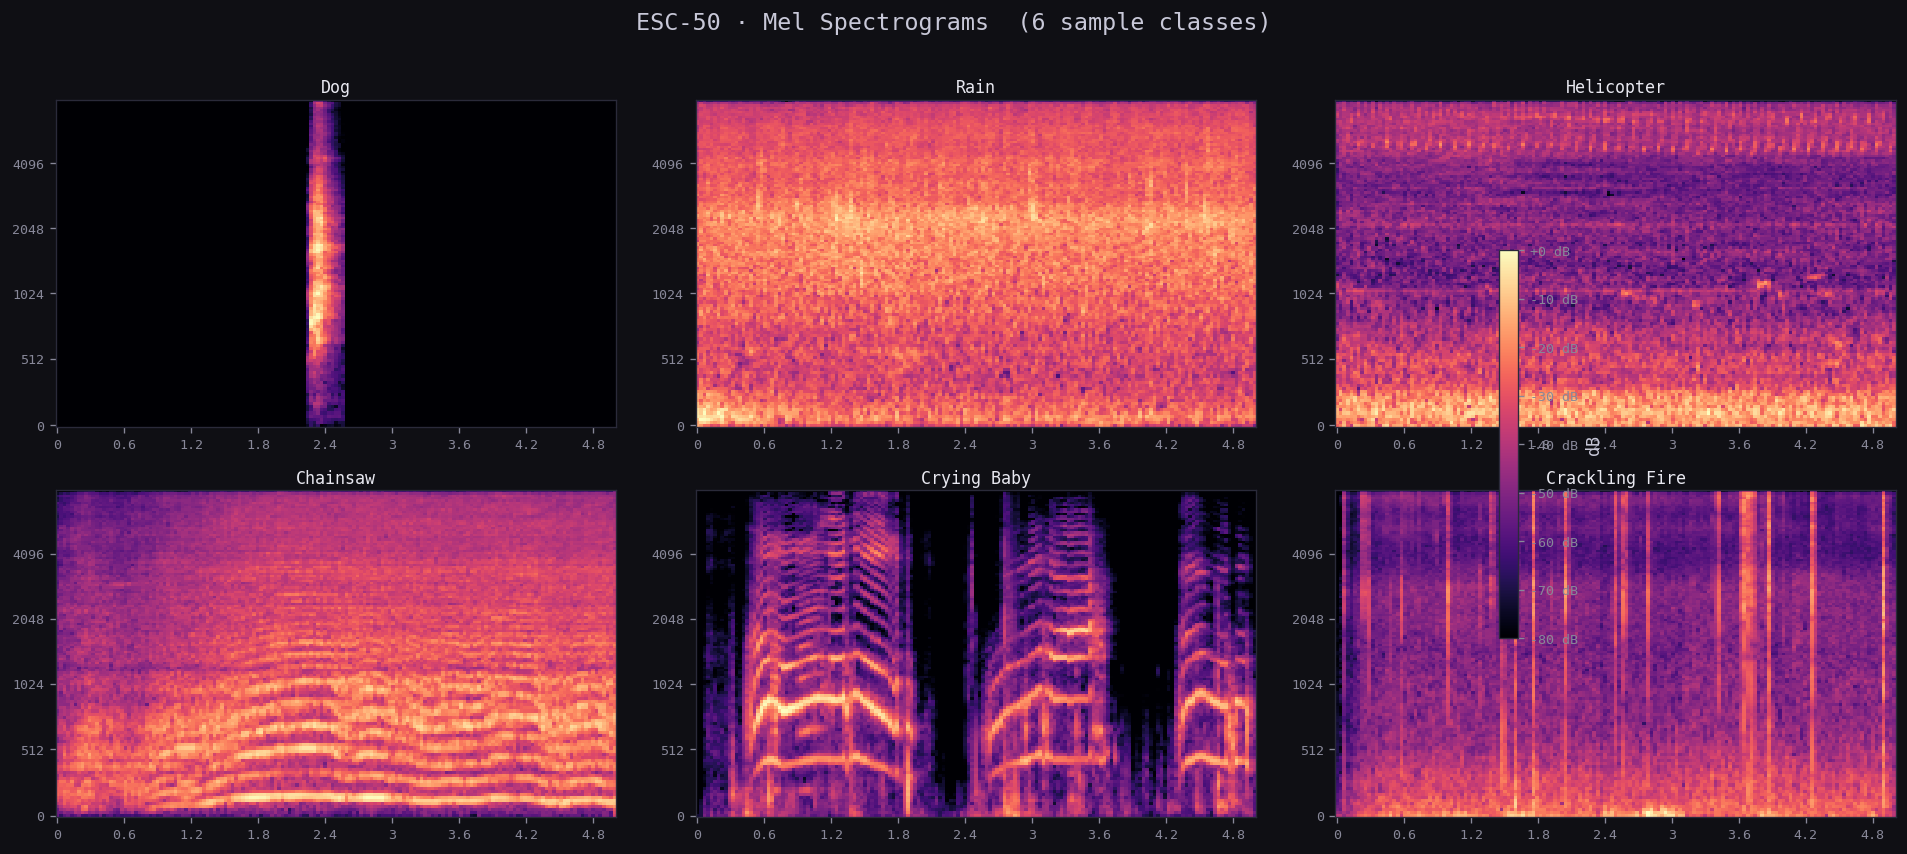

In [ ]:
# ── ESC-50: mel spectrograms for 6 diverse classes ──────────────────────────
SAMPLE_CLASSES_ESC = ['dog', 'rain', 'helicopter', 'chainsaw', 'crying_baby', 'crackling_fire']
# Fall back gracefully if a class name differs slightly in the CSV
available = esc_df['category'].unique()
SAMPLE_CLASSES_ESC = [c for c in SAMPLE_CLASSES_ESC if c in available]
if len(SAMPLE_CLASSES_ESC) < 6:
    SAMPLE_CLASSES_ESC += [c for c in available if c not in SAMPLE_CLASSES_ESC][:6 - len(SAMPLE_CLASSES_ESC)]

fig, axes = plt.subplots(2, 3, figsize=(16, 7))
fig.suptitle('ESC-50 · Mel Spectrograms  (6 sample classes)', fontsize=14, y=1.01)

for ax, cls in zip(axes.flat, SAMPLE_CLASSES_ESC):
    row     = esc_df[esc_df['category'] == cls].iloc[0]
    fpath   = ESC50_DIR / 'audio' / row['filename']
    try:
        y       = load_and_normalize(str(fpath))
        mel_db  = compute_melspec(y)
        img = librosa.display.specshow(
            mel_db, sr=TARGET_SR, hop_length=HOP_LENGTH,
            x_axis='time', y_axis='mel', ax=ax, cmap='magma'
        )
        ax.set_title(cls.replace('_', ' ').title(), fontsize=10, pad=4)
        ax.set_xlabel('')
        ax.set_ylabel('')
    except Exception as e:
        ax.set_title(f'{cls}\n[error]', fontsize=9)
        ax.text(0.5, 0.5, str(e), transform=ax.transAxes, ha='center', fontsize=7)

fig.colorbar(img, ax=axes, format='%+2.0f dB', shrink=0.6, label='dB')
fig.tight_layout()
plt.savefig(ROOT / 'outputs' / 'figures' / 'esc50_mel_spectrograms.png',
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

In [ ]:
# ── UrbanSound8K: mel spectrograms for all 10 classes ───────────────────────
urb_classes_list = sorted(urb_df['class'].unique())

fig, axes = plt.subplots(2, 5, figsize=(20, 7))
fig.suptitle('UrbanSound8K · Mel Spectrograms  (all 10 classes)', fontsize=14, y=1.01)

for ax, cls in zip(axes.flat, urb_classes_list):
    row   = urb_df[urb_df['class'] == cls].iloc[0]
    fpath = URBAN_DIR / 'audio' / f'fold{row["fold"]}' / row['slice_file_name']
    try:
        y      = load_and_normalize(str(fpath))
        mel_db = compute_melspec(y)
        img = librosa.display.specshow(
            mel_db, sr=TARGET_SR, hop_length=HOP_LENGTH,
            x_axis='time', y_axis='mel', ax=ax, cmap='inferno'
        )
        ax.set_title(cls.replace('_', ' ').title(), fontsize=9.5, pad=4)
        ax.set_xlabel('')
        ax.set_ylabel('')
    except Exception as e:
        ax.set_title(f'{cls}\n[error]', fontsize=9)
        ax.text(0.5, 0.5, str(e), transform=ax.transAxes, ha='center', fontsize=7)

fig.colorbar(img, ax=axes, format='%+2.0f dB', shrink=0.5, label='dB')
fig.tight_layout()
plt.savefig(ROOT / 'outputs' / 'figures' / 'urban_mel_spectrograms.png',
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

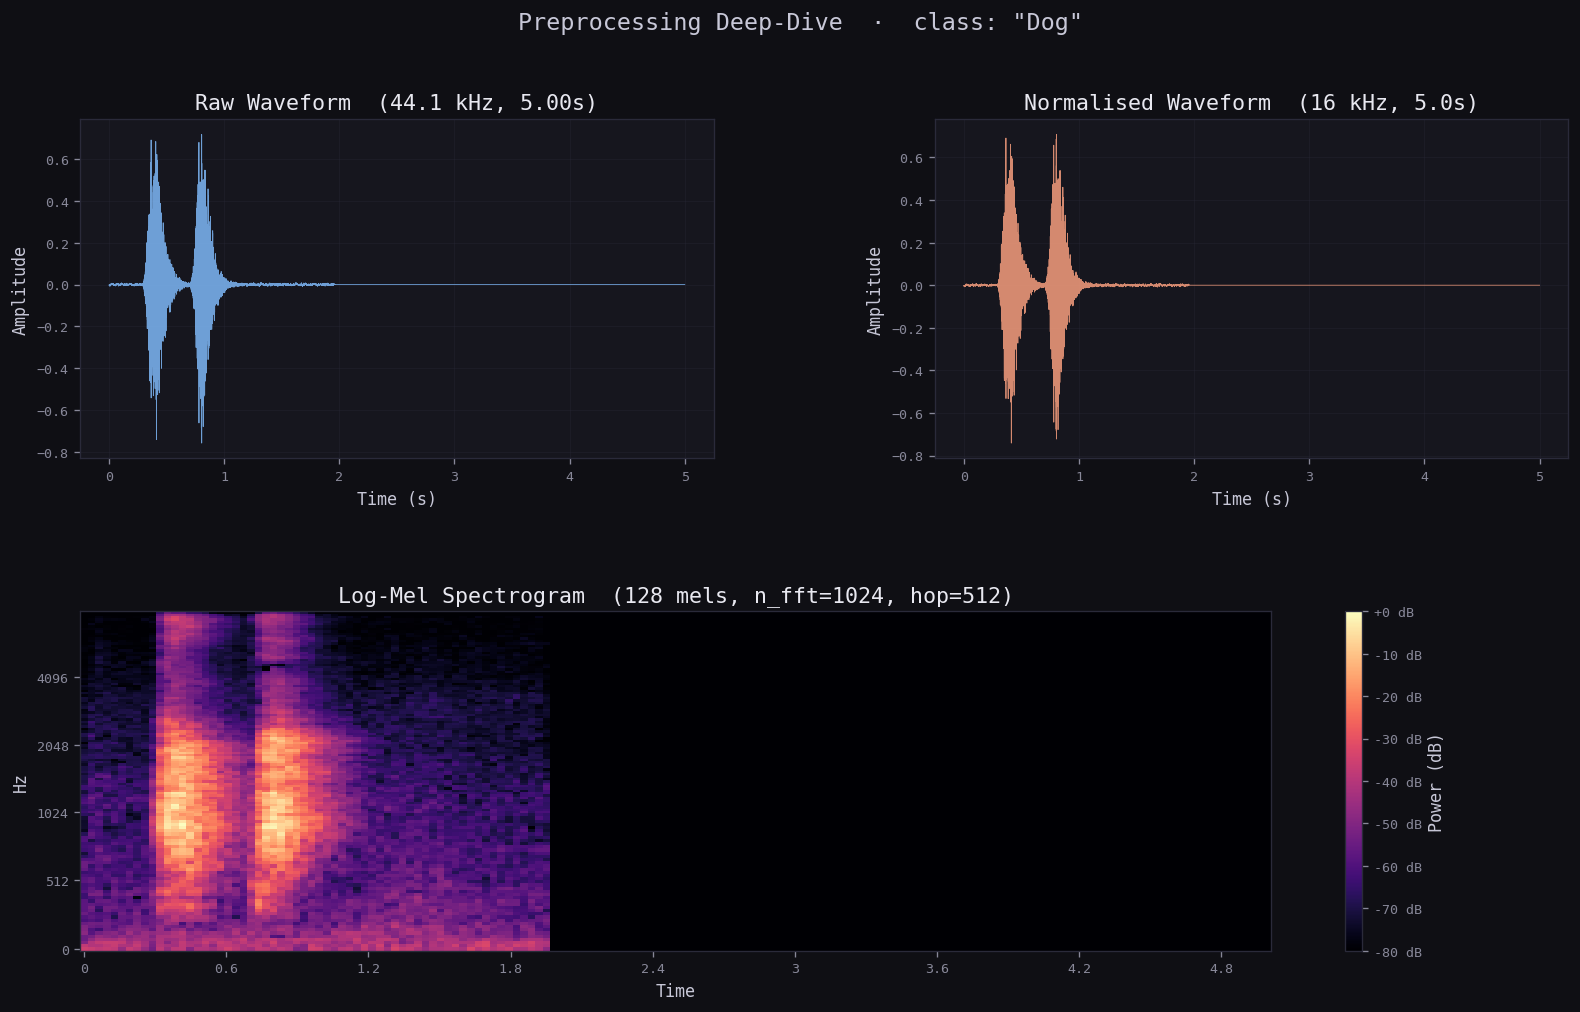

Sample: 3-163459-A-0.wav  |  class: Dog


In [ ]:
# ── Deep-dive: effect of preprocessing on a single clip ─────────────────────
# Pick one clip and show raw vs normalised vs mel
sample_row  = esc_df.sample(1, random_state=7).iloc[0]
sample_path = str(ESC50_DIR / 'audio' / sample_row['filename'])
cls_name    = sample_row['category'].replace('_', ' ').title()

# Load original (without resampling)
y_raw, sr_raw = librosa.load(sample_path, sr=None, mono=True)
# Load normalised
y_norm = load_and_normalize(sample_path)
mel_db = compute_melspec(y_norm)

fig = plt.figure(figsize=(16, 9))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle(f'Preprocessing Deep-Dive  ·  class: "{cls_name}"', fontsize=14)

# Raw waveform
ax1 = fig.add_subplot(gs[0, 0])
t_raw = np.linspace(0, len(y_raw)/sr_raw, len(y_raw))
ax1.plot(t_raw, y_raw, color=ESC_COLOR, lw=0.5, alpha=0.85)
ax1.set_title(f'Raw Waveform  ({sr_raw/1000:.1f} kHz, {len(y_raw)/sr_raw:.2f}s)')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Amplitude')
ax1.grid(alpha=0.3)

# Normalised waveform
ax2 = fig.add_subplot(gs[0, 1])
t_norm = np.linspace(0, TARGET_DUR, len(y_norm))
ax2.plot(t_norm, y_norm, color=URB_COLOR, lw=0.5, alpha=0.85)
ax2.set_title(f'Normalised Waveform  ({TARGET_SR/1000:.0f} kHz, {TARGET_DUR}s)')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Amplitude')
ax2.grid(alpha=0.3)

# Mel spectrogram (full)
ax3 = fig.add_subplot(gs[1, :])
img = librosa.display.specshow(
    mel_db, sr=TARGET_SR, hop_length=HOP_LENGTH,
    x_axis='time', y_axis='mel', ax=ax3, cmap='magma'
)
ax3.set_title(f'Log-Mel Spectrogram  ({N_MELS} mels, n_fft={N_FFT}, hop={HOP_LENGTH})')
plt.colorbar(img, ax=ax3, format='%+2.0f dB', label='Power (dB)')

plt.savefig(ROOT / 'outputs' / 'figures' / 'preprocessing_deepdive.png',
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'Sample: {sample_row["filename"]}  |  class: {cls_name}')

In [ ]:
# ── Mel spectrogram shape / tensor size reference ────────────────────────────
frames = 1 + (int(TARGET_SR * TARGET_DUR) // HOP_LENGTH)
print('=== Mel Spectrogram Tensor Shape ===')
print(f'  n_mels     = {N_MELS}')
print(f'  time frames= {frames}')
print(f'  → tensor shape (1 clip): ({N_MELS}, {frames})')
print(f'  → with batch dim       : (B, 1, {N_MELS}, {frames})   ← what the CNN will receive')
print(f'  Memory per clip (float32): {N_MELS * frames * 4 / 1024:.1f} KB')

=== Mel Spectrogram Tensor Shape ===
  n_mels     = 128
  time frames= 157
  → tensor shape (1 clip): (128, 157)
  → with batch dim       : (B, 1, 128, 157)   ← what the CNN will receive
  Memory per clip (float32): 78.5 KB


---
## 6. Summary & Preprocessing Notes <a id='6-summary'></a>

In [ ]:
# ── Consolidated findings ───────────────────────────────────────────────────
print('╔══════════════════════════════════════════════════════════════════════╗')
print('║           EXPLORATION SUMMARY & PREPROCESSING CHECKLIST             ║')
print('╠══════════════════════════════════════════════════════════════════════╣')
print('║  ESC-50                                                              ║')
print('║  ✅  Balanced — 40 clips per class, no weighting needed             ║')
print('║  ✅  Fixed duration — all clips exactly 5s                          ║')
print('║  ⚠   Sample rate is 44.1 kHz → resample to 16 kHz                  ║')
print('║  ⚠   Some clips may be stereo → convert to mono                     ║')
print('╠══════════════════════════════════════════════════════════════════════╣')
print('║  UrbanSound8K                                                        ║')
print('║  ⚠   Imbalanced — needs class weights or oversampling               ║')
print('║  ⚠   Variable duration (≤4s) → pad to 5s with silence              ║')
print('║  ⚠   Mixed sample rates → resample ALL to 16 kHz                   ║')
print('║  ⚠   Mixed channels → convert all to mono                          ║')
print('╠══════════════════════════════════════════════════════════════════════╣')
print('║  Mel Spectrogram Config (confirmed)                                  ║')
print(f'║  sample_rate={TARGET_SR}  n_fft={N_FFT}  hop={HOP_LENGTH}  n_mels={N_MELS}          ║')
print(f'║  Output tensor: (1, {N_MELS}, {frames}) per clip                           ║')
print('╚══════════════════════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════════════════════╗
║           EXPLORATION SUMMARY & PREPROCESSING CHECKLIST             ║
╠══════════════════════════════════════════════════════════════════════╣
║  ESC-50                                                              ║
║  ✅  Balanced — 40 clips per class, no weighting needed             ║
║  ✅  Fixed duration — all clips exactly 5s                          ║
║  ⚠   Sample rate is 44.1 kHz → resample to 16 kHz                  ║
║  ⚠   Some clips may be stereo → convert to mono                     ║
╠══════════════════════════════════════════════════════════════════════╣
║  UrbanSound8K                                                        ║
║  ⚠   Imbalanced — needs class weights or oversampling               ║
║  ⚠   Variable duration (≤4s) → pad to 5s with silence              ║
║  ⚠   Mixed sample rates → resample ALL to 16 kHz                   ║
║  ⚠   Mixed channels → convert all to mono                     

In [ ]:
# ── Figures saved ────────────────────────────────────────────────────────────
figures_dir = ROOT / 'outputs' / 'figures'
saved = sorted(figures_dir.glob('*.png'))
print(f'Figures saved to {figures_dir}:')
for f in saved:
    print(f'  📊 {f.name}')

Figures saved to C:\Users\shara\Desktop\ALM\outputs\figures:
  📊 duration_comparison.png
  📊 esc50_audio_stats.png
  📊 esc50_class_distribution.png
  📊 esc50_mel_spectrograms.png
  📊 preprocessing_deepdive.png
  📊 urban_audio_stats.png
  📊 urban_class_distribution.png
